#**Importazione delle librerie necessarie**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime

#**Download del file .csv**


In [ ]:
#oggi = datetime.date.today().strftime("%Y-%m-%d")
#oggi

'2026-07-25'

In [ ]:
msft = yf.download("MSFT", start="2023-01-01", end="2026-07-25", actions=True)

msft.to_csv("MSFT.csv")

/tmp/ipykernel_2050/2954222938.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  msft = yf.download("MSFT", start="2023-01-01", end=oggi, actions=True)
[*********************100%***********************]  1 of 1 completed


##Importazione del file csv in Python

In [ ]:
file = '/content/MSFT.csv'
df = pd.read_csv(file)
df.head()

,Price,Close,Dividends,High,Low,Open,Stock Splits,Volume
0,Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT,MSFT
1,Date,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-03,232.9482879638672,0.0,238.94749699304793,230.82862391751698,236.35140592714558,0.0,25740000
3,2023-01-04,222.7583770751953,0.0,226.42401047503648,219.7052947992431,225.8503455985308,0.0,50623400
4,2023-01-05,216.15626525878906,0.0,221.25122288452224,215.6214867654486,220.9109052515567,0.0,39585600


#**Pre-Processing del dataset**

In [ ]:
df_copy = df.copy()
df_copy = df_copy[["Price","Close"]]
df_copy = df_copy.drop([0,1], axis=0)
df_copy = df_copy.reset_index(drop=True)
df_copy = df_copy.rename(columns={'Price': 'Date'})
df_copy['Date'] = pd.to_datetime(df_copy['Date'])
df_copy = df_copy.set_index('Date')
df_copy

,Close
Date,
2023-01-03,232.9482879638672
2023-01-04,222.7583770751953
2023-01-05,216.15626525878906
2023-01-06,218.70376586914062
2023-01-09,220.83316040039062
...,...
2026-07-20,402.2900085449219
2026-07-21,397.75
2026-07-22,390.3399963378906


##Calcolo dei Rendimenti giornalieri e cumulati

In [ ]:
df_copy['Close'] = pd.to_numeric(df_copy['Close']) #trasformiamo i valori della colonna "Close" in numeri con la funzione pd.to_numeric
df_copy["Rend. GG"] = df_copy["Close"].pct_change() #calcoliamo i rendimenti giornalieri
df_copy["Rend. Cum."] = (1+df_copy["Rend. GG"]).cumprod()-1 #calcoliamo i rendimenti cumulati
df_copy

,Close,Rend. GG,Rend. Cum.
Date,,,
2023-01-03,232.948288,NaN,NaN
2023-01-04,222.758377,-0.043743,-0.043743
2023-01-05,216.156265,-0.029638,-0.072085
2023-01-06,218.703766,0.011785,-0.061149
2023-01-09,220.833160,0.009736,-0.052008
...,...,...,...
2026-07-20,402.290009,0.021507,0.726950
2026-07-21,397.750000,-0.011285,0.707460
2026-07-22,390.339996,-0.018630,0.675651


##Calcolo delle Medie Mobili per diverse finestre temporali e della Volatilità

In [ ]:
df_copy['MA20']=df_copy["Close"].rolling(window=20).mean()
df_copy['MA50']=df_copy["Close"].rolling(window=50).mean()
df_copy['MA200']=df_copy["Close"].rolling(window=200).mean()
df_copy["volatility20"]=df_copy['Rend. GG'].rolling(window=20).std()*np.sqrt(252)
df_copy


,Close,Rend. GG,Rend. Cum.,MA20,MA50,MA200,volatility20
Date,,,,,,,
2023-01-03,232.948288,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-04,222.758377,-0.043743,-0.043743,NaN,NaN,NaN,NaN
2023-01-05,216.156265,-0.029638,-0.072085,NaN,NaN,NaN,NaN
2023-01-06,218.703766,0.011785,-0.061149,NaN,NaN,NaN,NaN
2023-01-09,220.833160,0.009736,-0.052008,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2026-07-20,402.290009,0.021507,0.726950,382.301997,401.098606,437.295963,0.366313
2026-07-21,397.750000,-0.011285,0.707460,383.822498,400.656393,436.702517,0.347077
2026-07-22,390.339996,-0.018630,0.675651,384.642497,400.178737,436.091746,0.352112


##Calcolo dei DrawDown

In [ ]:
df_copy["Close_max"] = df_copy["Close"].cummax()
df_copy["Drawdown"] = (df_copy["Close"] - df_copy["Close_max"]) / df_copy["Close_max"]
df_copy

,Close,Rend. GG,Rend. Cum.,MA20,MA50,MA200,volatility20,Close_max,Drawdown
Date,,,,,,,,,
2023-01-03,232.948288,NaN,NaN,NaN,NaN,NaN,NaN,232.948288,0.000000
2023-01-04,222.758377,-0.043743,-0.043743,NaN,NaN,NaN,NaN,232.948288,-0.043743
2023-01-05,216.156265,-0.029638,-0.072085,NaN,NaN,NaN,NaN,232.948288,-0.072085
2023-01-06,218.703766,0.011785,-0.061149,NaN,NaN,NaN,NaN,232.948288,-0.061149
2023-01-09,220.833160,0.009736,-0.052008,NaN,NaN,NaN,NaN,232.948288,-0.052008
...,...,...,...,...,...,...,...,...,...
2026-07-20,402.290009,0.021507,0.726950,382.301997,401.098606,437.295963,0.366313,538.658508,-0.253163
2026-07-21,397.750000,-0.011285,0.707460,383.822498,400.656393,436.702517,0.347077,538.658508,-0.261592
2026-07-22,390.339996,-0.018630,0.675651,384.642497,400.178737,436.091746,0.352112,538.658508,-0.275348


#**Dataset finale**

In [ ]:
df_copy = df_copy.drop(df_copy.index[0])
df_copy

,Close,Rend. GG,Rend. Cum.,MA20,MA50,MA200,volatility20,Close_max,Drawdown
Date,,,,,,,,,
2023-01-04,222.758377,-0.043743,-0.043743,NaN,NaN,NaN,NaN,232.948288,-0.043743
2023-01-05,216.156265,-0.029638,-0.072085,NaN,NaN,NaN,NaN,232.948288,-0.072085
2023-01-06,218.703766,0.011785,-0.061149,NaN,NaN,NaN,NaN,232.948288,-0.061149
2023-01-09,220.833160,0.009736,-0.052008,NaN,NaN,NaN,NaN,232.948288,-0.052008
2023-01-10,222.515259,0.007617,-0.044787,NaN,NaN,NaN,NaN,232.948288,-0.044787
...,...,...,...,...,...,...,...,...,...
2026-07-20,402.290009,0.021507,0.726950,382.301997,401.098606,437.295963,0.366313,538.658508,-0.253163
2026-07-21,397.750000,-0.011285,0.707460,383.822498,400.656393,436.702517,0.347077,538.658508,-0.261592
2026-07-22,390.339996,-0.018630,0.675651,384.642497,400.178737,436.091746,0.352112,538.658508,-0.275348


#**Statistiche**

In [ ]:
df_stat = df_copy [["Close","Rend. GG","Rend. Cum.","Drawdown"]]
df_stat.describe()

,Close,Rend. GG,Rend. Cum.,Drawdown
count,891.000000,891.000000,891.000000,891.000000
mean,396.247716,0.000679,0.701011,-0.085164
std,70.093164,0.015797,0.300896,0.084945
min,216.156265,-0.099931,-0.072085,-0.344984
25%,358.959198,-0.007404,0.540939,-0.116025
50%,404.837433,0.001025,0.737885,-0.061188
75%,434.345703,0.009361,0.864558,-0.017864
max,538.658508,0.101337,1.312352,0.000000


#**Grafici**

In [ ]:
plt.rcParams["figure.figsize"] = [12,6]

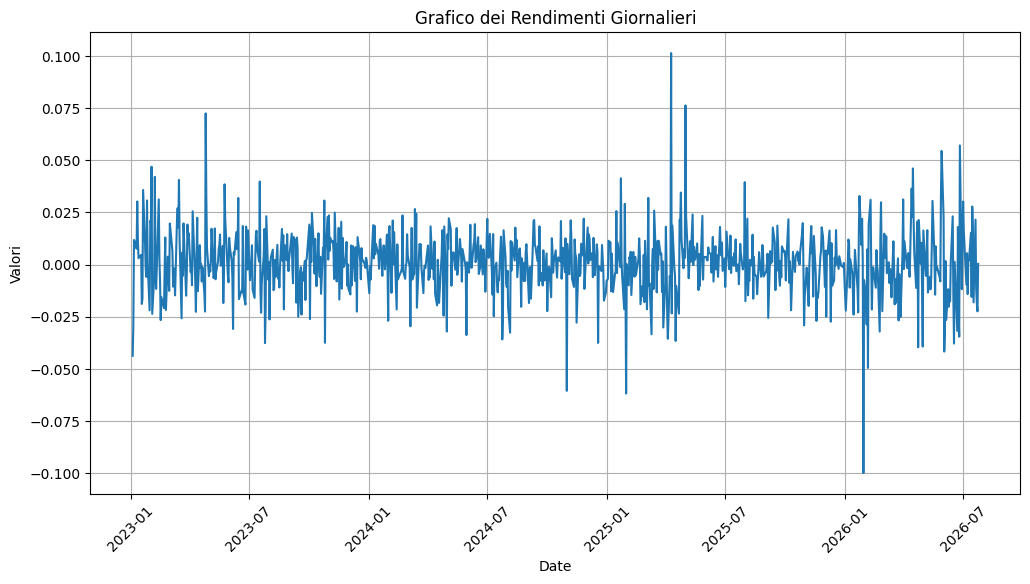

In [ ]:
plt.title("Grafico dei Rendimenti Giornalieri")
plt.xlabel("Date")
plt.ylabel("Valori")
plt.xticks(rotation=45)
plt.grid()
plt.plot(df_copy["Rend. GG"])
plt.show()

In [ ]:
for idx, value in df_copy['Rend. GG'].items():
  if value > 0.05 or value < -0.05:
    print(f"Index: {idx}, Rend. GG: {value}")

Index: 2023-04-26 00:00:00, Rend. GG: 0.0724345655615255
Index: 2024-10-31 00:00:00, Rend. GG: -0.06052758140979908
Index: 2025-01-30 00:00:00, Rend. GG: -0.061809126158054895
Index: 2025-04-09 00:00:00, Rend. GG: 0.10133694520155268
Index: 2025-05-01 00:00:00, Rend. GG: 0.07625345985014453
Index: 2026-01-29 00:00:00, Rend. GG: -0.0999314476548332
Index: 2026-05-29 00:00:00, Rend. GG: 0.05445092515456418
Index: 2026-06-26 00:00:00, Rend. GG: 0.05708135763656941


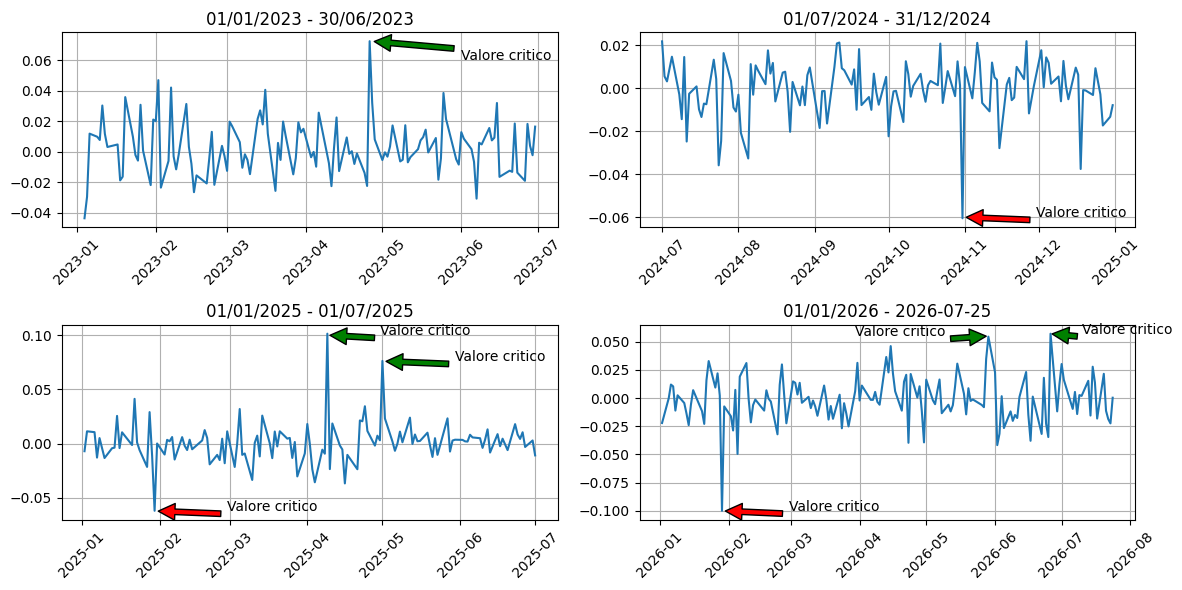

In [ ]:
#Grafico 1
plt.subplot(2,2,1)
df_range1 = df_copy.loc["2023-01-01":"2023-06-30"]
plt.title("01/01/2023 - 30/06/2023")
plt.xticks(rotation=45)
plt.grid()
plt.annotate("Valore critico", xy=(pd.to_datetime("2023-04-26"), 0.0725), #punto da annotare
             xytext=(pd.to_datetime("2023-06-01"), 0.06), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor="green", shrink=0.05),) #proprietà della freccia
plt.plot(df_range1["Rend. GG"])


#Grafico 2
plt.subplot(2,2,2)
df_range2 = df_copy.loc["2024-07-01":"2024-12-31"]
plt.title("01/07/2024 - 31/12/2024")
plt.xticks(rotation=45)
plt.grid()
plt.annotate("Valore critico", xy=(pd.to_datetime("2024-10-31"), -0.06), #punto da annotare
             xytext=(pd.to_datetime("2024-11-30"), -0.06), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor="red", shrink=0.05),) #proprietà della freccia
plt.plot(df_range2["Rend. GG"])


#Grafico 3
plt.subplot(2,2,3)
df_range3 = df_copy.loc["2025-01-01":"2025-07-01"]
plt.title("01/01/2025 - 01/07/2025")
plt.xticks(rotation=45)
plt.grid()
plt.annotate("Valore critico", xy=(pd.to_datetime("2025-01-30"), -0.062), #punto da annotare
             xytext=(pd.to_datetime("2025-02-28"), -0.062), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor="red", shrink=0.05),) #proprietà della freccia
plt.annotate("Valore critico", xy=(pd.to_datetime("2025-04-09"), 0.1), #punto da annotare
             xytext=(pd.to_datetime("2025-04-30"), 0.1), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor="green", shrink=0.05),) #proprietà della freccia
plt.annotate("Valore critico", xy=(pd.to_datetime("2025-05-01"), 0.076), #punto da annotare
             xytext=(pd.to_datetime("2025-05-30"), 0.076), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor="green", shrink=0.05),) #proprietà della freccia
plt.plot(df_range3["Rend. GG"])


#Grafico 4
plt.subplot(2,2,4)
df_range4 = df_copy.loc["2026-01-01":f"{oggi}"]
plt.title(f"01/01/2026 - {oggi}")
plt.xticks(rotation=45)
plt.grid()
plt.plot(df_range4["Rend. GG"])
plt.annotate("Valore critico", xy=(pd.to_datetime("2026-01-29"), -0.1), #punto da annotare
             xytext=(pd.to_datetime("2026-02-28"), -0.1), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor="red", shrink=0.05),) #proprietà della freccia
plt.annotate("Valore critico", xy=(pd.to_datetime("2026-05-29"), 0.055), #punto da annotare
             xytext=(pd.to_datetime("2026-03-30"), 0.055), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor="green", shrink=0.05),) #proprietà della freccia
plt.annotate("Valore critico", xy=(pd.to_datetime("2026-06-26"), 0.057), #punto da annotare
             xytext=(pd.to_datetime("2026-07-10"), 0.057), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor="green", shrink=0.05),) #proprietà della freccia
plt.tight_layout()
plt.show()


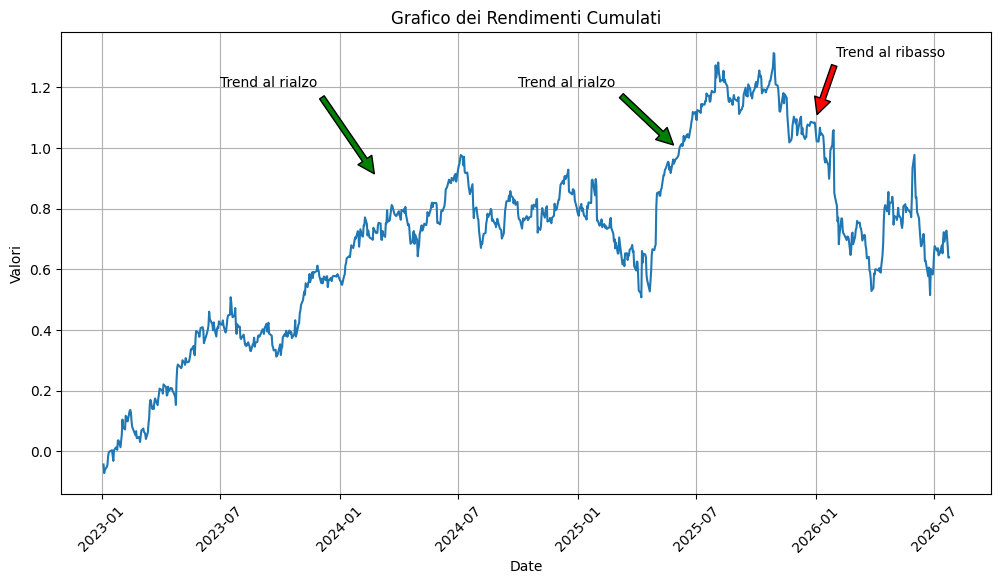

In [ ]:
plt.title("Grafico dei Rendimenti Cumulati")
plt.xlabel("Date")
plt.ylabel("Valori")
plt.xticks(rotation=45)
plt.grid()
plt.annotate("Trend al rialzo", xy=(pd.to_datetime("2024-02-28"), 0.9), #punto da annotare
             xytext=(pd.to_datetime("2023-07-01"), 1.2), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor='green', shrink=0.05),) #proprietà della freccia
plt.annotate("Trend al rialzo", xy=(pd.to_datetime("2025-06-01"), 1), #punto da annotare
             xytext=(pd.to_datetime("2024-10-01"), 1.2), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor='green', shrink=0.05),) #proprietà della freccia
plt.annotate("Trend al ribasso", xy=(pd.to_datetime("2026-01-01"), 1.1), #punto da annotare
             xytext=(pd.to_datetime("2026-02-01"), 1.3), #punto dove inserire il testo dell'annotazione
             arrowprops=dict(facecolor='red', shrink=0.05),) #proprietà della freccia
plt.plot(df_copy["Rend. Cum."])
plt.show()

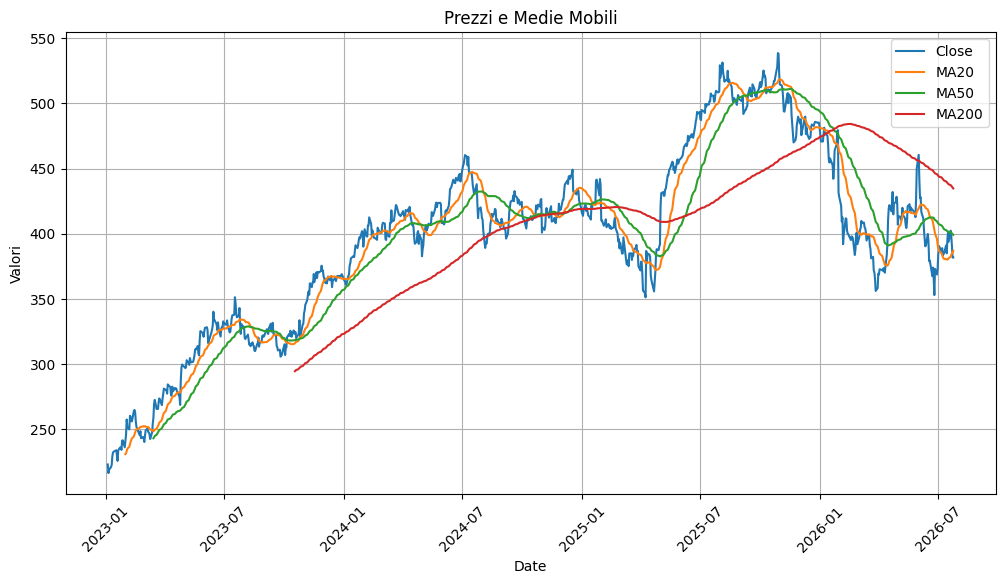

In [ ]:
df_close = df_copy[["Close", "MA20","MA50","MA200"]]
plt.title("Prezzi e Medie Mobili")
plt.xlabel("Date")
plt.ylabel("Valori")
plt.xticks(rotation=45)
plt.grid()
plt.plot(df_close["Close"], label="Close")
plt.plot(df_close["MA20"], label="MA20")
plt.plot(df_close["MA50"], label="MA50")
plt.plot(df_close["MA200"], label="MA200")
plt.legend()
plt.show()

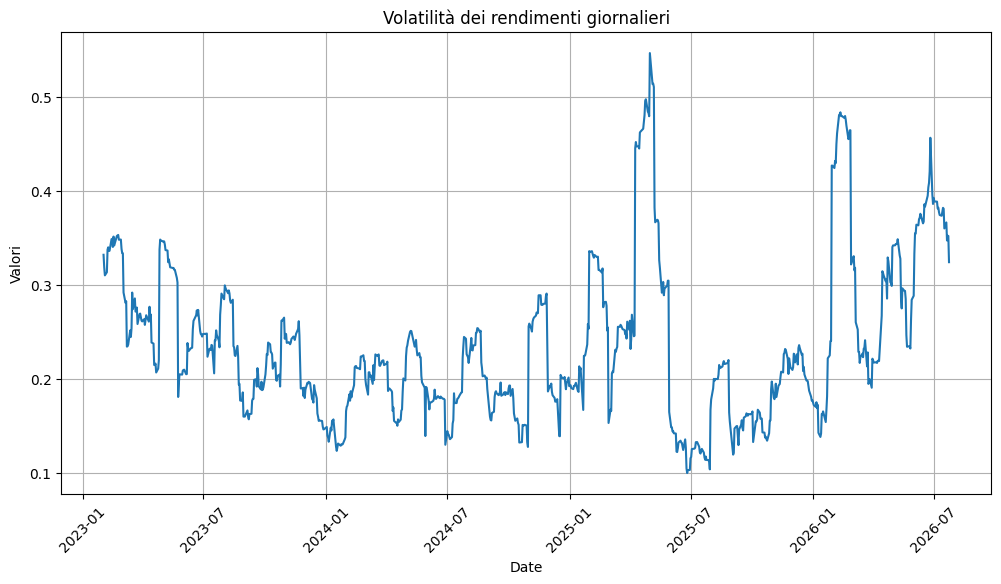

In [ ]:
plt.title("Volatilità dei rendimenti giornalieri")
plt.xlabel("Date")
plt.ylabel("Valori")
plt.xticks(rotation=45)
plt.grid()
plt.plot(df_copy["volatility20"])
plt.show()

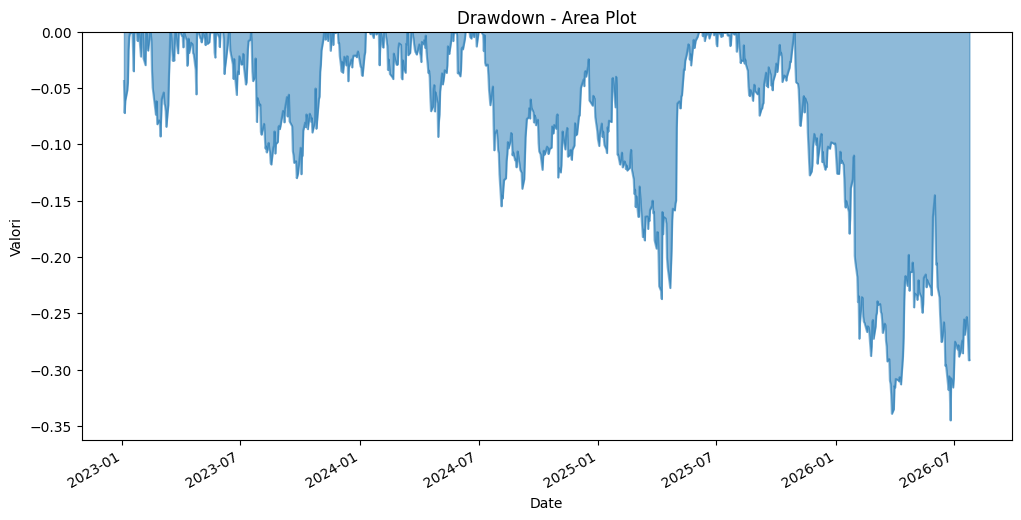

In [ ]:
plt.title("Drawdown - Area Plot")
plt.xlabel("Date")
plt.ylabel("Valori")
plt.xticks(rotation=45)
plt.grid()
df_copy["Drawdown"].plot.area(stacked=False, alpha=0.5)
plt.show()

#**Interpretazione dei grafici (al 25/07/2026)**
##**Grafico dei rendimenti giornalieri**
Osservando il grafico dei rendimenti giornalieri si riscontrano valori particolarmente positivi nella prima metà degli anni 2023 e 2025 e valori sostanzialmente negativi nella seconda metà dell'anno 2024, prima metà 2025 e 2026.

##**Grafico dei rendimenti cumulati**
Osservando il grafico dei rendimenti cumulati, oltre a confermare le precedenti conclusioni, possiamo notare un **trend crescente** del titolo da inizio 2023 fino a metà anno 2024.

Successivamente al trend si riscontra un periodo in cui i rendimenti cumulati del titolo sono pressocché stabili (seconda metà del 2024) per poi seguire un **trend decrescente** durato per tutta la prima metà del 2025.

Nel 3° trimestre del 2025 i rendimenti cumulati aumentano vertiginosamente, restano pressocché stabili per un breve periodo per poi dimunuire altrettanto vertiginosamente nell'ultimo trimestre.

Nel 2026 presentano pressocché lo stesso andamento della seconda parte del 2025, assumendo valori meno rilevanti.

##**Grafico di prezzi e medie mobili**
Osservando il grafico dei prezzi e delle medie mobili possiamo notare che i primi si collocano quasi sempre al di sopra delle medie mobili. Fanno particolare eccezione quasi tutta la prima parte dell'anno 2025 e, soprattutto, da inizio 2026 ad oggi (25/07/2026).

##**Grafico della volatilità dei rendimenti giornalieri**
Osservando il grafico della volatilità dei rendimenti giornalieri si può notare che il titolo è stato caratterizzato da una elevata volatitlità nella prima parte del 2025 e nella prima parte del 2026

##**Interpretazione delle Statistiche**
La media dei rendimenti giornalieri è quasi pari a 0 mentre quella dei rendimenti cumulati è circa 0.7.
Ciò vuol dire che il titolo ha un rendimento medio giornaliero di circa 0.0007, mentre in 3 anni ha un rendimento medio di circa 0.7 (senza considerare ulteriori costi). In altre parole, il suo **rendimento medio sia giornaliero e sia cumulato per il periodo considerato non è elevato**.

D'altra parte, la volatilità dei rendimenti giornalieri dimostra che il  titolo ha un **livello di rischio elevato**: osservando il grafico della "volatility20" è facile notare che la deviazione standard annualizzati si colloca quasi sempre tra 0.2 e 0.3, arrivando a superare il 50% nella prima metà del 2025 e il 40% nel 2026. Attualmente è al di sopra del 30%, soglia di riferimento per classificare un titolo ad alto rischio.

#**Strategie di investimento**

Il titolo sta vivendo un periodo di alta volatilità a causa dei vari eventi che stannno accadendo negli ultimi tempi (es. chiusura dello stretto di Hormuz, guerra tra America ed Iran). Pertanto si consiglia a FinSafe Corp di attendere che esso ritorni stabile prima di programmare una strategia di investimento.